## Mixed-Integer Linear Programming Formulation with Embedded Machine Learning Surrogates for the Design of Chemical Process Families

In this small example, we will use a transcritical $\text{CO}_2$ refrigeration system with four unit modules. 

We have the following problem specifications:

- We aim to design a family of 56 process variants ($|V|=56$) where each variant $v \in V$ is described by its maximum outside air temperature $T^{\text{max}}_v$ and required capacity $C^{\text{min}}_v$. 

- Additionally, we aim to design the evaporator area, compressor area, and compressor design flow commonly as apart of the process platform $\mathcal{P}$. 

- We can select 2 out of 10 possible evaporator areas, 2 out of 14 possible condender areas, and 2 out of 10 possible compressor design flows.

- This indicates the data (data/transcritical-co2-data.csv) should consist of $56 \times 10 \times 14 \times 10 = 78,400$ data points; which, indeed, it does.

In this notebook, we will first train a set of piecewise-linear ML surrogates using the data provided, and then embed them within the ML surrogates optimization formulation.

To learn more about the problem formulation and process family design in general, refer to the following publication.

> Stinchfield, Georgia, Joshua C. Morgan, Sakshi Naik, Lorenz T. Biegler, John C. Eslick, Clas Jacobson, David C. Miller et al. "A mixed integer linear programming approach for the design of chemical process families." Computers & Chemical Engineering 183 (2024): 108620.

In [2]:
import os
import numpy as np
from process_family.type.surrogates import SurrogatesProcessFamily
from process_family.utils.parameters.surrogates import SurrogateParameters

### Data Preparation & Initialization

Given the dataset described above, the process_family package will organize the data into the necessary sets and perform minor preprocessing tasks to prepare the data. 

We need to specify the following information, which should be initialized within the Parameters object offer within the process_family package:

- string path to the data file.
- list of string names of columns corresponding to the process variant descriptions (in this case, it is the columns corresponding to $T^{\text{max}}_v$ and $C^{\text{min}}_v$).
- list of string names of columns corresponding to the common unit module design elements (in this case, it is the columns corresponding to the evaporator area, condenser area, and compressor design flow).
- string name of column with True/False entries indicating if a particular simulation (or optimization) of a variant $v \in V$ with a given set of common unit module designs was successfully solved or not; in another sense, this is the feasibility.
- string name of column corresponding to the total annualized cost of a particular variant $v \in V$ with a particular set of common unit module designs.
- dictionary, where the keys are the string names of the columns corresponding to the common unit module design elements and the values correspond to the total (integer) number of each common design we can select (i.e., for the evaporator area, this would be 2 because we only want to select 2 of the 10 considered).
- dictionary, where the keys are the string names of the columns corresponding to the common unit module design elements and the values correspond to a list of labels used for identifying the common unit module designs selected within the platform $\mathcal{P}$.

In [3]:
# initialize parameters
params = SurrogateParameters("transcritical-co2")

# init path to csv file with transcritical co2 data
params.csv_filepath=os.path.join(params.cwd,"data/transcritical-co2-data.csv")

# (1) factors defining each process variant (must match with .csv file names)
params.process_variant_columns=[
                            "Capacity", 
                            "Outside Air Temperature"
                        ]

# (2) common unit module types (must match with .csv file names)
params.common_unit_types_column=[
                            "Evaporator Area",
                            "Condenser Area",
                            "Compressor Design Flow"
                        ]

# (3) col. of .csv file that corresponds to the "success" of each simulation
params.feasibility_column=["Success"]

# (4) col. of .csv file that corresponds to the total annualized cost of each simulation
params.annualized_cost_column=["Total Annualized Cost"]

# (5) max. num of designs offered for each common unit module type
#     one key per entry in common_unit_module_types
params.num_common_unit_type_designs={
                                "Evaporator Area":2,
                                "Condenser Area":2,
                                "Compressor Design Flow":2
                            }

# define the labels for each of the common unit type designs allowable.
params.labels_for_common_unit_module_designs ={
                                            "Evaporator Area": range(2),
                                            "Condenser Area": range(2),
                                            "Compressor Design Flow": range(2) 
                                        }

# individual unit module design cost data
params.unit_module_capex_columns = {
                                    "Evaporator Area": 'Annualized Capital Evaporator Cost',
                                    "Condenser Area": 'Annualized Capital Condenser Cost',
                                    "Compressor Design Flow": 'Annualized Capital Compressor Cost'
                                    }

params.process_variant_column_names = ["Capacity (tons)", 
                                        "Max. Outside Air Temperature (deg. C)"]
params.common_module_type_column_names = ["Evap. Area ($m^2$)",
                                        "Cond. Area ($m^2$)",
                                        "Compr. Flow (mol./s)"]
params.make_results_dir("surrogates")

### Training Machine Learning Models: Predicting Cost & Feasibility

We need to train two models - one to predict if a combination of units will be feasible for a particular variant (i.e., classification task) and one to estimate the total annualized cost of investing and operating a design for a particular variant. Based on the initialized Parameters object, as shown above, we can simply pass this to the NNTrainer or the TreeTrainer provided within the package. Given the parameterized information, we know how the surrogates should look in terms of inputs and outputs.

There is also the option to bypass this step and load your own model in directly.

In [4]:
from process_family.utils.trainer.nn import NNTrainer
from process_family.utils.trainer.tree import TreeTrainer

cwd = os.getcwd()
surrogates_dir = os.path.join(cwd, f"surrogates/")

nn_trainer = NNTrainer(params = params, 
                       label = "transcritical-co2")

total number of costs = 78400
total number of unique costs = 4513




We can train a ReLU activated neural network to predict for the classification of feasibility. Send the task kwdarg as "linear-classification". 

If there are hyperparamters you want to tune yourself, you can turn hp_tuning off; otherwise, we will employ some basic hyper parameter tuning supported for keras/tensorflow models.

Trial 25 Complete [00h 00m 03s]
accuracy: 0.9552055797955349

Best accuracy So Far: 0.9683588649320042
Total elapsed time: 00h 01m 00s
Epoch 1/5000
1963/1963 ━━━━━━━━━━━━━━━━━━━━ 1s 374us/step - accuracy: 0.7646 - loss: 0.4794 - val_accuracy: 0.9205 - val_loss: 0.3139
Epoch 2/5000
1963/1963 ━━━━━━━━━━━━━━━━━━━━ 1s 316us/step - accuracy: 0.9332 - loss: 0.3028 - val_accuracy: 0.9412 - val_loss: 0.2833
Epoch 3/5000
1963/1963 ━━━━━━━━━━━━━━━━━━━━ 1s 321us/step - accuracy: 0.9511 - loss: 0.2806 - val_accuracy: 0.9705 - val_loss: 0.2716
Epoch 4/5000
1963/1963 ━━━━━━━━━━━━━━━━━━━━ 1s 316us/step - accuracy: 0.9710 - loss: 0.2697 - val_accuracy: 0.9754 - val_loss: 0.2629
Epoch 5/5000
1963/1963 ━━━━━━━━━━━━━━━━━━━━ 1s 315us/step - accuracy: 0.9757 - loss: 0.2615 - val_accuracy: 0.9761 - val_loss: 0.2566
Epoch 6/5000
1963/1963 ━━━━━━━━━━━━━━━━━━━━ 1s 314us/step - accuracy: 0.9771 - loss: 0.2555 - val_accuracy: 0.9765 - val_loss: 0.2521
Epoch 7/5000
1963/1963 ━━━━━━━━━━━━━━━━━━━━ 1s 315us/step - a

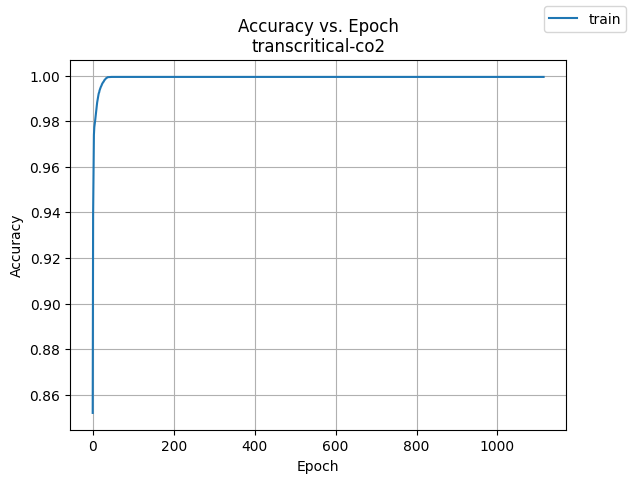

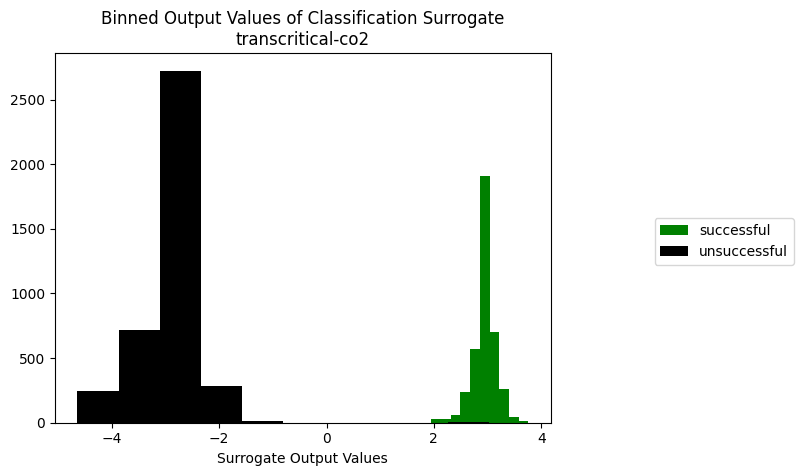

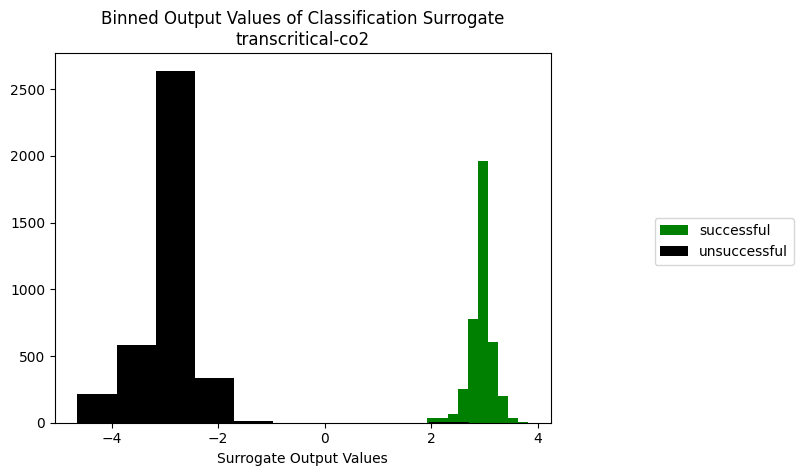

In [4]:
nn_trainer.train_nn(directory = surrogates_dir,
                    task = "linear-classification",
                    plot_metrics = True,
                    hp_tuning = True)

We can also train a ReLU activated neural network to perform the regression task of predicting the cost.

Trial 25 Complete [00h 00m 01s]
mean_squared_error: 0.007315968835936387

Best mean_squared_error So Far: 0.0026320272095540606
Total elapsed time: 00h 00m 35s
Epoch 1/5000
1963/1963 ━━━━━━━━━━━━━━━━━━━━ 1s 335us/step - loss: 0.0994 - mae: 0.2634 - mean_squared_error: 0.0994 - val_loss: 0.0483 - val_mae: 0.1697 - val_mean_squared_error: 0.0483
Epoch 2/5000
1963/1963 ━━━━━━━━━━━━━━━━━━━━ 1s 314us/step - loss: 0.0411 - mae: 0.1490 - mean_squared_error: 0.0411 - val_loss: 0.0265 - val_mae: 0.1081 - val_mean_squared_error: 0.0265
Epoch 3/5000
1963/1963 ━━━━━━━━━━━━━━━━━━━━ 1s 305us/step - loss: 0.0246 - mae: 0.1012 - mean_squared_error: 0.0246 - val_loss: 0.0199 - val_mae: 0.0906 - val_mean_squared_error: 0.0199
Epoch 4/5000
1963/1963 ━━━━━━━━━━━━━━━━━━━━ 1s 305us/step - loss: 0.0191 - mae: 0.0862 - mean_squared_error: 0.0191 - val_loss: 0.0166 - val_mae: 0.0820 - val_mean_squared_error: 0.0166
Epoch 5/5000
1963/1963 ━━━━━━━━━━━━━━━━━━━━ 1s 307us/step - loss: 0.0160 - mae: 0.0782 - mean_sq

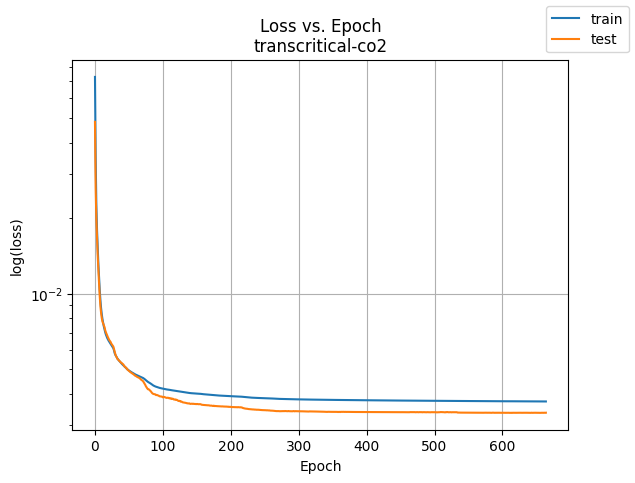

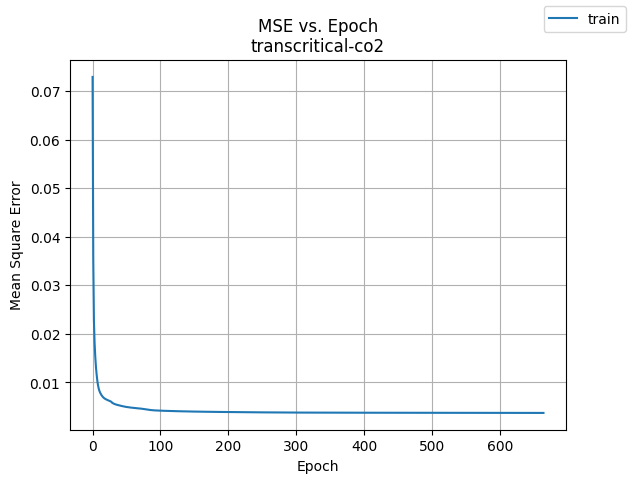

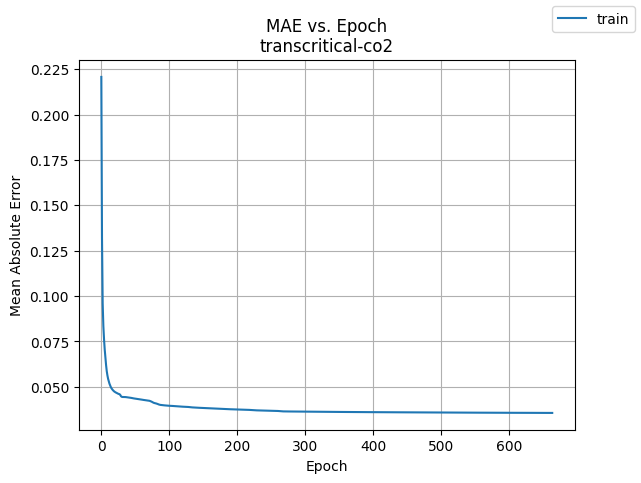

In [5]:
nn_trainer.train_nn(directory = surrogates_dir,
                    task = "regression",
                    plot_metrics = True,
                    hp_tuning = True)

Tree based models, specifically LMDT (Linear Model Decision Tree) and GBDT (Gradient Boosted Decision Tree) are also supported. In this case, we initialize a tree trainer.

In [9]:
tree_trainer = TreeTrainer(params = params, 
                           label = "transcritical-co2")

total number of costs = 78400
total number of unique costs = 4513




We can train a LMDT (Linear Model Decision Tree) to perform the cost regression task. 

Note, while we can certainly train a classification of the LMDT (at least using the classifier Tree object offered in linear-tree) for this case study, at the time of publication, OMLT does not support this on the backend, so we will skip this model configuration.

In [6]:
tree_trainer.train_lmdt(directory = surrogates_dir,
                        task = "regression",
                        hp_tune = True)

Fitting 3 folds for each of 160 candidates, totalling 480 fits
Best Hyperparameters = LinearTreeRegressor(base_estimator=LinearRegression(), max_bins=12,
                    max_depth=11, min_samples_leaf=5)
LMDT training accuracy = 0.999990685738573
LMDT testing accuracy = 0.9999901297434005


LinearTreeRegressor(base_estimator=LinearRegression(), max_bins=12,
                    max_depth=11, min_samples_leaf=5)

We can train a GBDT to perform the classification feasibility task. 

Note, while we can certainly train a classification of the GBDT (at least using the classifier Tree object offered in linear-tree) for this case study, at the time of publication, OMLT does not support this on the backend. Here, rather than skipping this configuration, we can train a classically regression based surrogate (MSE loss) that is trained on the 0-1, True-False data. This requires passing the task kwdarg as "classification-regression".

[LightGBM] [Warning] min_data_in_leaf is set=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
[LightGBM] [Warning] num_iterations is set=10, num_trees=10 will be ignored. Current value: num_iterations=10
[LightGBM] [Warning] min_data_in_leaf is set=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000236 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 49
[LightGBM] [Info] Number of data points in the train set: 41865, number of used features: 5
[LightGBM] [Info] Start training from score 0.489956
[LightGBM] [Warning] min_data_in_leaf is set=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
[LightGBM] [Warning] min_data_in_leaf is set=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
[LightG

LGBMRegressor(max_depth=50, metric='mse', min_data_in_leaf=1, num_trees=100,
              objective='regression', random_state=1)

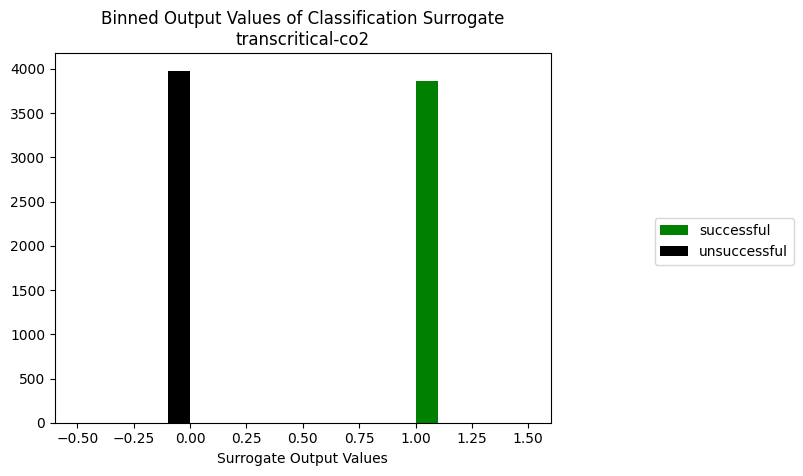

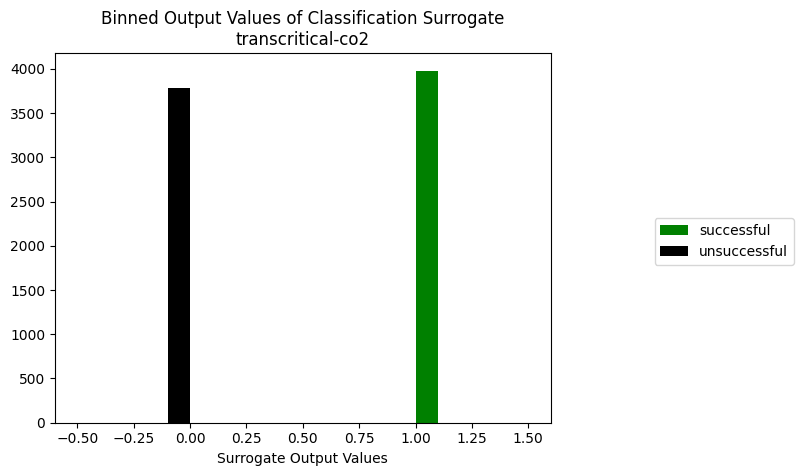

In [10]:
tree_trainer.train_gbdt(directory = surrogates_dir,
                        task = "classification-regression",
                        plot_metrics = True,
                        hp_tune = True)

And, finally, we can also train a GBDT to perform the regression cost prediction task.

In [8]:
tree_trainer.train_gbdt(directory = surrogates_dir,
                        task = "regression",
                        plot_metrics = True,
                        hp_tune = True)

[LightGBM] [Warning] min_data_in_leaf is set=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
[LightGBM] [Warning] num_iterations is set=10, num_trees=10 will be ignored. Current value: num_iterations=10
[LightGBM] [Warning] min_data_in_leaf is set=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000336 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 47
[LightGBM] [Info] Number of data points in the train set: 20669, number of used features: 5
[LightGBM] [Info] Start training from score 0.128569
[LightGBM] [Warning] min_data_in_leaf is set=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
[LightGBM] [Warning] min_data_in_leaf is set=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
[LightGBM] [Warning] num_iterations is set=10, num_trees=10 will be ign

LGBMRegressor(max_depth=50, metric='mse', min_data_in_leaf=15, num_trees=100,
              objective='regression', random_state=1)

## Solving the Process Family Design Problem

Now that we have our surrogates trained, we need to select the ones we want to use to actually embed within the overall optimization formulation. Here, we will use both the GBDT's. You can easily plug in other models, to quickly test what is the best combination of models that gives you your desired accuracy and solution speed.

In [ ]:
 # grab paths to surrogates
cwd = os.getcwd()
classification_surrogate = os.path.join(cwd, f"surrogates/classification-regression-gbdt")
regression_surrogate = os.path.join(cwd, f"surrogates/regression-gbdt")

# add surrogates we want
params.add_surrogates(classification_type = "gbdt",
                      classification_path = classification_surrogate,
                      regression_type = "gbdt",
                      regression_path = regression_surrogate,
                      classification_threshold = 0.99)

# add in the output scaling
params.regression_scaling["offset_outputs"] = np.array([0], dtype="float32")
params.regression_scaling["factor_outputs"] = np.array([1], dtype="float32")

['_Booster', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__sklearn_clone__', '__sklearn_is_fitted__', '__sklearn_tags__', '__str__', '__subclasshook__', '__weakref__', '_base_doc', '_best_iteration', '_best_score', '_build_request_for_signature', '_check_feature_names', '_check_n_features', '_class_map', '_class_weight', '_classes', '_doc_link_module', '_doc_link_template', '_doc_link_url_param_generator', '_estimator_type', '_evals_result', '_get_default_requests', '_get_doc_link', '_get_metadata_request', '_get_param_names', '_get_tags', '_more_tags', '_n_classes', '_n_features', '_n_features_in', '_objective', '_other_params', '_process_n_jobs', '_process_params', '_repr_html_', '_repr_html_inner', '_

And now we can solve the optimization problem.

In [28]:
# create the surrogates based process family
spfd = SurrogatesProcessFamily(params)

# build & solve surrogates formulation
spfd.build_model(params.labels_for_common_unit_module_designs)
spfd.solve_model()

total number of costs = 78400
total number of unique costs = 4513


	the classification surrogate is a gradient boosted tree.
	the regression surrogate is a gradient boosted tree.
Set parameter Username
Set parameter LicenseID to value 2649923
Academic license - for non-commercial use only - expires 2026-04-10
skipping further warning of this kind
Read LP format model from file /var/folders/44/14_qr9yx01zcg633lzkm1nt80000gn/T/tmp304nhdcm.pyomo.lp
Reading time = 0.89 seconds
x1: 697707 rows, 353310 columns, 3385374 nonzeros
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (mac64[arm] - Darwin 24.6.0 24G84)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 697707 rows, 353310 columns and 3385374 nonzeros
Model fingerprint: 0x9b16b824
Variable types: 348606 continuous, 4704 integer (4704 binary)
Coefficient statistics:
  Matrix range     [3e-08, 1e+02]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 2e+0


Variant:
	 Capacity = 80
	 Outside Air Temperature = 28
Common Unit Module Designs Selected:
	 Evaporator Area = 52.22
	 Condenser Area = 20.0
	 Compressor Design Flow = 67.5

Variant:
	 Capacity = 80
	 Outside Air Temperature = 29
Common Unit Module Designs Selected:
	 Evaporator Area = 52.22
	 Condenser Area = 20.0
	 Compressor Design Flow = 67.5

Variant:
	 Capacity = 80
	 Outside Air Temperature = 30
Common Unit Module Designs Selected:
	 Evaporator Area = 52.22
	 Condenser Area = 20.0
	 Compressor Design Flow = 67.5

Variant:
	 Capacity = 80
	 Outside Air Temperature = 31
Common Unit Module Designs Selected:
	 Evaporator Area = 52.22
	 Condenser Area = 20.0
	 Compressor Design Flow = 67.5

Variant:
	 Capacity = 80
	 Outside Air Temperature = 32
Common Unit Module Designs Selected:
	 Evaporator Area = 52.22
	 Condenser Area = 20.0
	 Compressor Design Flow = 67.5

Variant:
	 Capacity = 80
	 Outside Air Temperature = 33
Common Unit Module Designs Selected:
	 Evaporator Area = 52.22


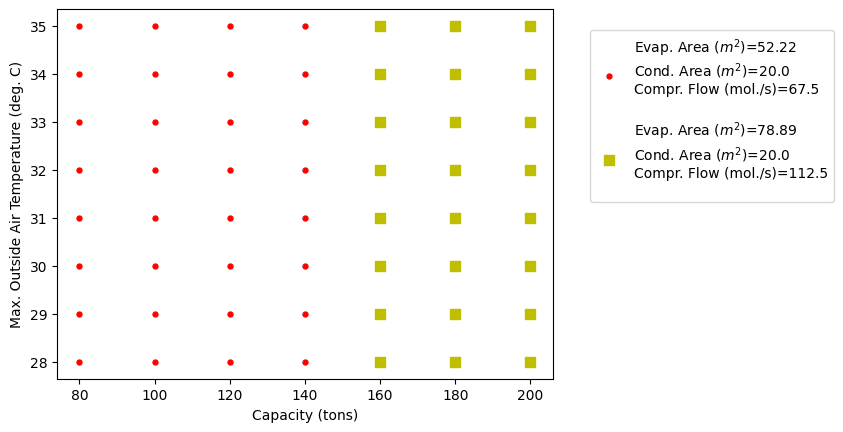

In [30]:
# plot results, store in plot_pathstring
plot_pathstring = os.path.join(params.results_dir, "surrogates-results.png")
spfd.plot(directory=plot_pathstring,
        process_variant_column_names = params.process_variant_column_names,
        common_module_type_columns = params.common_module_type_column_names)

results_pathstring=os.path.join(params.results_dir,"surrogates-results.txt")
spfd.results_summary(directory=results_pathstring)

Feel free to compare the results here to the ones in discretized.ipynb. They are certainly different, as to be expected, but when comparing the designs that are selected (i.e., the legend) and how the layout of the plot looks, we can see that there is clearly a similarity along decision boundaries.

In [31]:
from datetime import datetime
print("Notebook last run on:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

Notebook last run on: 2025-08-18 10:37:06
